# 03 · Exploratory Data Analysis
Built on the star schema (`data/processed/mart`). All data is synthetic.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
MART = "data/processed/mart/"
from python.analysis.kpis import sales_view
mart = {n: pd.read_csv(MART + f'{n}.csv') for n in ['FactSales','FactReturns','FactSupport','DimDate','DimCustomer','DimProduct','DimRegion','DimChannel']}
mart['DimDate']['date'] = pd.to_datetime(mart['DimDate']['date'])
s = sales_view(mart)
s.shape

(106860, 38)

In [2]:
kpi = pd.read_csv('data/outputs/kpis/headline_kpis.csv').set_index('kpi')['value']
kpi

,value
kpi,
total_revenue,"386,259,523.12"
total_cost,"317,030,137.83"
total_profit,"69,229,385.29"
profit_margin_pct,17.92
total_orders,"54,640.00"
total_customers,"8,802.00"
units_sold,"155,312.00"
aov,"7,069.17"
orders_per_customer,6.20


## Trend & seasonality

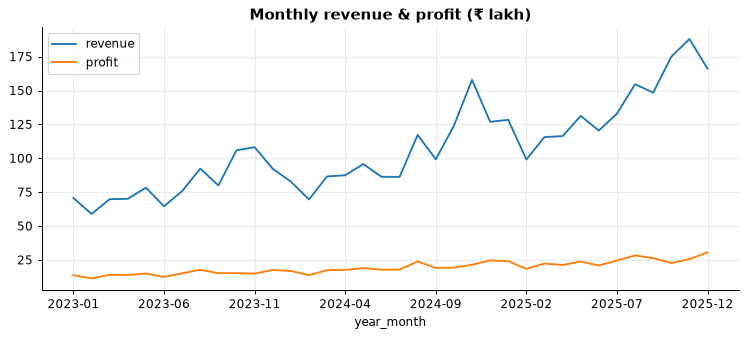

,revenue,profit,orders,yoy_%
year_month,,,,
2025-01,"12,837,583.70","2,398,794.60",1610,55.10
2025-02,"9,907,197.10","1,833,718.90",1278,42.40
2025-03,"11,561,415.80","2,232,360.00",1560,33.50
2025-04,"11,632,048.30","2,123,459.60",1506,33.00
2025-05,"13,127,291.70","2,373,245.20",1643,37.20
2025-06,"12,044,560.40","2,083,687.20",1494,39.50
2025-07,"13,295,570.40","2,451,684.80",1663,54.20
2025-08,"15,459,261.40","2,831,140.90",1978,31.90
2025-09,"14,843,391.00","2,626,317.20",1777,49.60


In [3]:
mo = s.groupby('year_month').agg(revenue=('net_revenue','sum'), profit=('profit','sum'), orders=('order_id','nunique'))
mo['yoy_%'] = mo.revenue.pct_change(12)*100
ax = (mo[['revenue','profit']]/1e5).plot(figsize=(10,3.8), title='Monthly revenue & profit (₹ lakh)')
plt.show()
mo.tail(12).round(1)

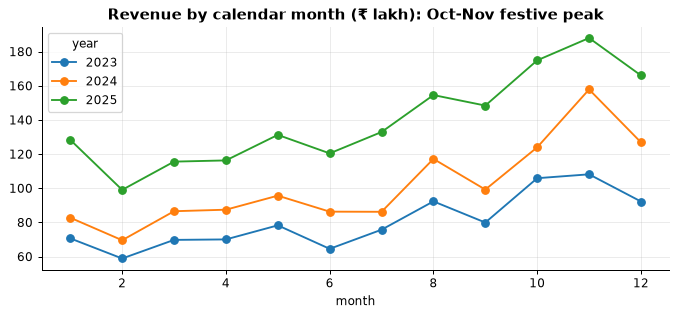

In [4]:
season = s.groupby(['year','month'])['net_revenue'].sum().unstack(0)/1e5
season.plot(figsize=(9,3.5), marker='o', title='Revenue by calendar month (₹ lakh): Oct-Nov festive peak'); plt.show()

## Category, region and channel mix

In [5]:
cat = s.groupby('category').agg(revenue=('net_revenue','sum'), profit=('profit','sum'), returned=('is_returned','mean'))
cat['margin_%'] = 100*cat.profit/cat.revenue; cat['return_rate_%'] = 100*cat.returned
cat.sort_values('revenue', ascending=False).round(2)

,revenue,profit,returned,margin_%,return_rate_%
category,,,,,
Electronics,"248,684,559.23","21,579,824.11",0.09,8.68,8.56
Fashion,"45,383,315.75","20,531,736.28",0.17,45.24,16.63
Home & Kitchen,"41,726,308.29","12,673,630.43",0.07,30.37,6.79
Sports,"19,915,491.10","6,589,441.11",0.07,33.09,7.45
Grocery,"15,503,675.59","2,354,956.09",0.01,15.19,1.22
Beauty,"9,478,789.98","4,097,700.35",0.05,43.23,5.06
Books,"5,316,477.92","1,351,319.99",0.03,25.42,3.48
Unknown,"250,905.26","50,776.93",0.08,20.24,8.33


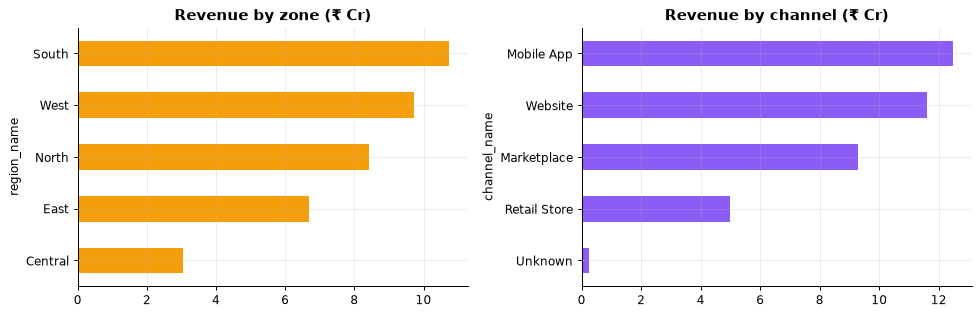

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.6))
(s.groupby('region_name').net_revenue.sum().sort_values()/1e7).plot.barh(ax=ax[0], title='Revenue by zone (₹ Cr)', color='#F59E0B')
(s.groupby('channel_name').net_revenue.sum().sort_values()/1e7).plot.barh(ax=ax[1], title='Revenue by channel (₹ Cr)', color='#8B5CF6')
plt.tight_layout(); plt.show()

## Discounts vs profitability

In [7]:
b = pd.cut(s.discount_pct, [-0.01, 0, .10, .20, .6], labels=['0%','1-10%','11-20%','>20%'])
g = s.groupby(b, observed=True).agg(revenue=('net_revenue','sum'), profit=('profit','sum'), lines=('sales_key','count'))
g['margin_%'] = 100*g.profit/g.revenue
g.round(2)

,revenue,profit,lines,margin_%
discount_pct,,,,
0%,"68,247,531.30","17,135,905.50",17406,25.11
1-10%,"231,640,832.86","43,443,453.62",63171,18.75
11-20%,"83,106,280.95","8,646,801.81",25119,10.40
>20%,"3,264,878.01","3,224.36",1164,0.10


## Order value distribution

count     54640.0
mean       7069.0
std       10874.0
min          99.0
25%        1308.0
50%        3084.0
75%        8537.0
90%       18367.0
99%       46630.0
max      333175.0
Name: net_revenue, dtype: float64


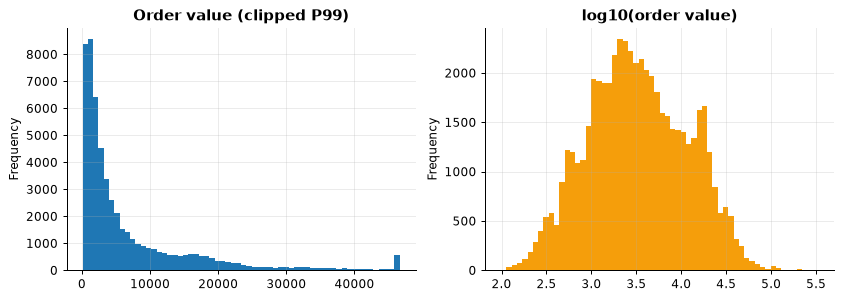

In [8]:
ov = s.groupby('order_id').net_revenue.sum()
print(ov.describe(percentiles=[.25,.5,.75,.9,.99]).round(0))
fig, ax = plt.subplots(1,2, figsize=(11,3.5))
ov.clip(upper=ov.quantile(.99)).plot.hist(bins=60, ax=ax[0], title='Order value (clipped P99)')
np.log10(ov).plot.hist(bins=60, ax=ax[1], color='#F59E0B', title='log10(order value)')
plt.show()

## Operations: returns, delivery, support

In [9]:
print(mart['FactReturns'].return_reason.value_counts().to_string())
sup = mart['FactSupport'].groupby('ticket_category').agg(tickets=('ticket_id','count'), median_h=('resolution_hours','median'), csat=('csat_score','mean'))
sup.sort_values('tickets', ascending=False).round(2)

return_reason
Size/Fit Issue          2188
Defective Product       1442
Damaged in Transit      1352
Not as Described        1343
Changed Mind            1298
Wrong Item Delivered     590
Late Delivery            522
Not Specified             88


,tickets,median_h,csat
ticket_category,,,
Delivery Delay,1663,27.60,3.70
Return/Refund,1586,35.20,3.47
Product Query,1312,16.60,4.01
Payment Issue,838,30.00,3.61
Product Defect,746,40.50,3.43
Account/Login,547,13.00,4.07
